# **Weather Prediction Project Using Deep Learning**

> ## Info About Dataset 

The most popular Australian weather prediction dataset is the "Rain in Australia" dataset. Sourced from the Australian Bureau of Meteorology (BoM), it features over 140,000 daily observations across 49 locations and is primarily used for binary classification to predict whether it will rain the following day. 

> ## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras import regularizers  # this is used for L1 and L2 regularization
# L1 regularization is a technique that penalizes the model for having large weights,
# while L2 regularization penalizes the model for having large weights and also encourages the model to have small weights
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score

> ## Load Data set

In [4]:
df=pd.read_csv('weatherAUS.csv')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

> ## Missing Values

In [7]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [11]:
# Let see percentage of missing values
df.isnull().sum() * 100 / len(df)

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64

> ## Imputation

In [12]:
from sklearn.impute import SimpleImputer
# creating if else function so that we can impute the missing value

for col in df.columns:
    if df[col].dtype == 'object':  # Categorical
        imputer = SimpleImputer(strategy='most_frequent')
    else:  # Numeric
        imputer = SimpleImputer(strategy='mean')

    df[[col]] = imputer.fit_transform(df[[col]])

df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

> ## Label Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,396,2,13.4,22.9,0.6,5.468232,7.611178,13,44.0,13,...,71.0,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8,0,0
1,397,2,7.4,25.1,0.0,5.468232,7.611178,14,44.0,6,...,44.0,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3,0,0
2,398,2,12.9,25.7,0.0,5.468232,7.611178,15,46.0,13,...,38.0,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2,0,0
3,399,2,9.2,28.0,0.0,5.468232,7.611178,4,24.0,9,...,45.0,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5,0,0
4,400,2,17.5,32.3,1.0,5.468232,7.611178,13,41.0,1,...,82.0,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7,0,0


> ## Building the model

In [15]:
# Selecting features and target
X = df.drop(['RainTomorrow'], axis=1)
y = df['RainTomorrow']

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Step 3: Build ANN Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Step 4: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train Model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


# Step 6: Evaluate & Predict
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7618 - loss: 1.9456 - val_accuracy: 0.8073 - val_loss: 0.8620
Epoch 2/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7880 - loss: 0.7399 - val_accuracy: 0.6642 - val_loss: 0.7615
Epoch 3/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7964 - loss: 0.5637 - val_accuracy: 0.7922 - val_loss: 0.4502
Epoch 4/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8044 - loss: 0.4908 - val_accuracy: 0.8345 - val_loss: 0.3834
Epoch 5/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8125 - loss: 0.4530 - val_accuracy: 0.8070 - val_loss: 0.5697
Epoch 6/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8225 - loss: 0.4153 - val_accuracy: 0.8166 - val_loss: 0.4706
Epoch 7/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8205 - loss: 0.4133 - val_accuracy: 0.8375 - val_loss: 0.3801
Epoch 8/20
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8293 - loss: 0.39

In [16]:

y_pred=model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Final Accuracy: {accuracy:.4f}")

910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
✅ Final Accuracy: 0.8337


<Axes: >

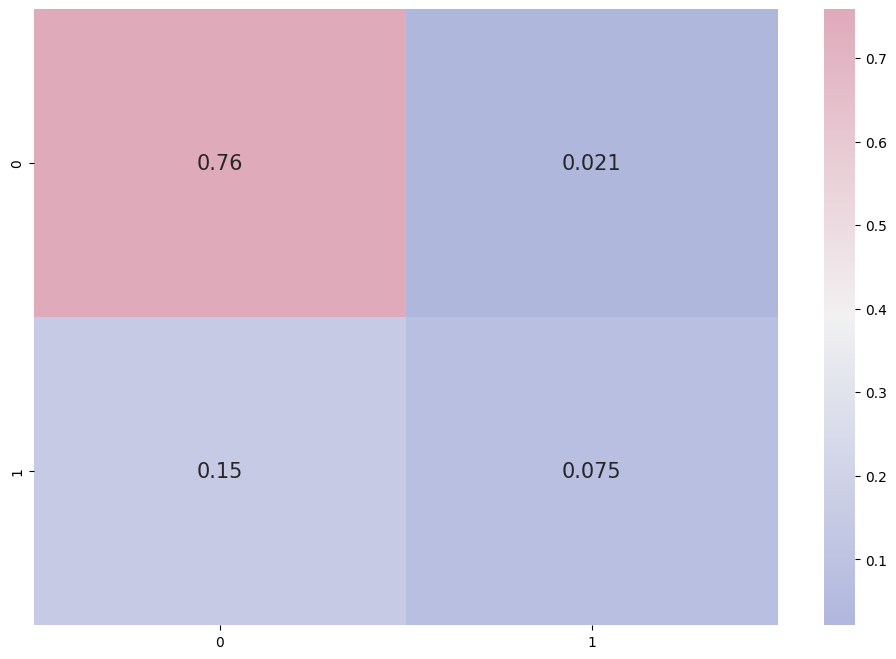

In [17]:
# confusion matrix
cmap1 = sns.diverging_palette(260,-10,s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12,8))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), cmap = cmap1, annot = True, annot_kws = {'size':15})

> ## Add Call Back Function

In [18]:

X = df[['Location','MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday',]]
y = df["RainTomorrow"]

# Splitting test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Step 3: Build ANN Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Step 4: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, epochs=50, batch_size=32,
          validation_split=0.2, callbacks=[early_stop])

# Step 6: Evaluate & Predict
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

Epoch 1/50


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7724 - loss: 0.9702 - val_accuracy: 0.8378 - val_loss: 0.3938
Epoch 2/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8009 - loss: 0.5375 - val_accuracy: 0.7015 - val_loss: 0.6178
Epoch 3/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8125 - loss: 0.4573 - val_accuracy: 0.7856 - val_loss: 0.8777
Epoch 4/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8158 - loss: 0.4414 - val_accuracy: 0.8375 - val_loss: 0.3794
Epoch 5/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8234 - loss: 0.4113 - val_accuracy: 0.8320 - val_loss: 0.3909
Epoch 6/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8241 - loss: 0.4036 - val_accuracy: 0.8393 - val_loss: 0.3783
Epoch 7/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8307 - loss: 0.3903 - val_accuracy: 0.8376 - val_loss: 0.3811
Epoch 8/50
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8363 - loss: 0.3827 - val_acc

---